## **Advanced Machine Learning (Assignment 1)**
---
---

Università degli Studi Milano Bicocca \
CdLM Informatica — A.A 2025/2026

---
---

#### **Componenti del gruppo:**
— Oleksandra Golub (856706)

---
---

Link al dataset che ho utilizzato: [Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset?select=bank.csv)

---
---



### **Librerie**
---
---


In [312]:
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import scipy.stats as st
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, classification_report

# Set seed per riproducibilità, rende deterministica la casualità di NumPy e di TensorFlow
np.random.seed(42)
tf.random.set_seed(42)

print("Librerie importate con successo!")

Librerie importate con successo!



### **Caricamento dati**
---
---


In [313]:
# Download del dataset
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
print("Path to dataset files:", path)

# Lista i file nella directory scaricata
files = os.listdir(path)
print("File disponibili:", files)

# Caricamento del CSV
for file in files:
    if file.endswith('.csv'):
        dataset_path = os.path.join(path, file)
        print(f"\nCaricamento file: {file}")
        break

# Caricamento del dataset
df = pd.read_csv(dataset_path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset
File disponibili: ['bank.csv']

Caricamento file: bank.csv



### **Esplorazione del dataset**
---
---


In [314]:
print("\nDimensioni dataset:", df.shape)


Dimensioni dataset: (11162, 17)


In [315]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [316]:
print("\nPrime righe del dataset:")
print(df.head())


Prime righe del dataset:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [317]:
# Tipi di dato per capire se servono cast
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [318]:
# Verificare la presenza di valori mancanti (nulli) in ogni colonna
print("\nValori mancanti per colonna:")
df.isnull().sum()


Valori mancanti per colonna:


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [319]:
df.duplicated().sum()

np.int64(0)

In [320]:
print("\nInfo sul dataset:")
df.info()


Info sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [321]:
print("\nStatistiche descrittive:")
print(df.describe())


Statistiche descrittive:
                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       

In [322]:
print("\nDistribuzione della variabile target:")
print(df.iloc[:, -1].value_counts())



Distribuzione della variabile target:
deposit
no     5873
yes    5289
Name: count, dtype: int64


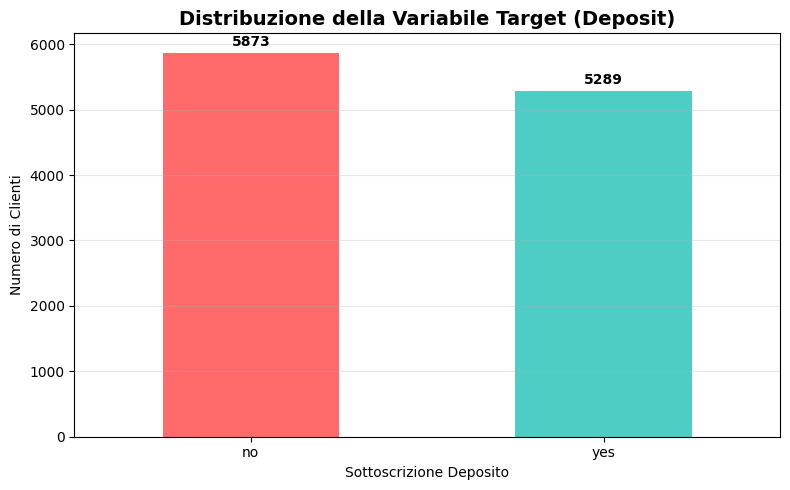

 Percentuale 'yes': 47.38%
 Percentuale 'no': 52.62%


In [323]:
# Visualizzazione distribuzione del target
plt.figure(figsize=(8, 5))
df['deposit'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribuzione della Variabile Target (Deposit)', fontsize=14, fontweight='bold')
plt.xlabel('Sottoscrizione Deposito')
plt.ylabel('Numero di Clienti')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(df['deposit'].value_counts()):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f" Percentuale 'yes': {(df['deposit']=='yes').sum()/len(df)*100:.2f}%")
print(f" Percentuale 'no': {(df['deposit']=='no').sum()/len(df)*100:.2f}%")

Quindi questo dataset è praticamente bilanciato!

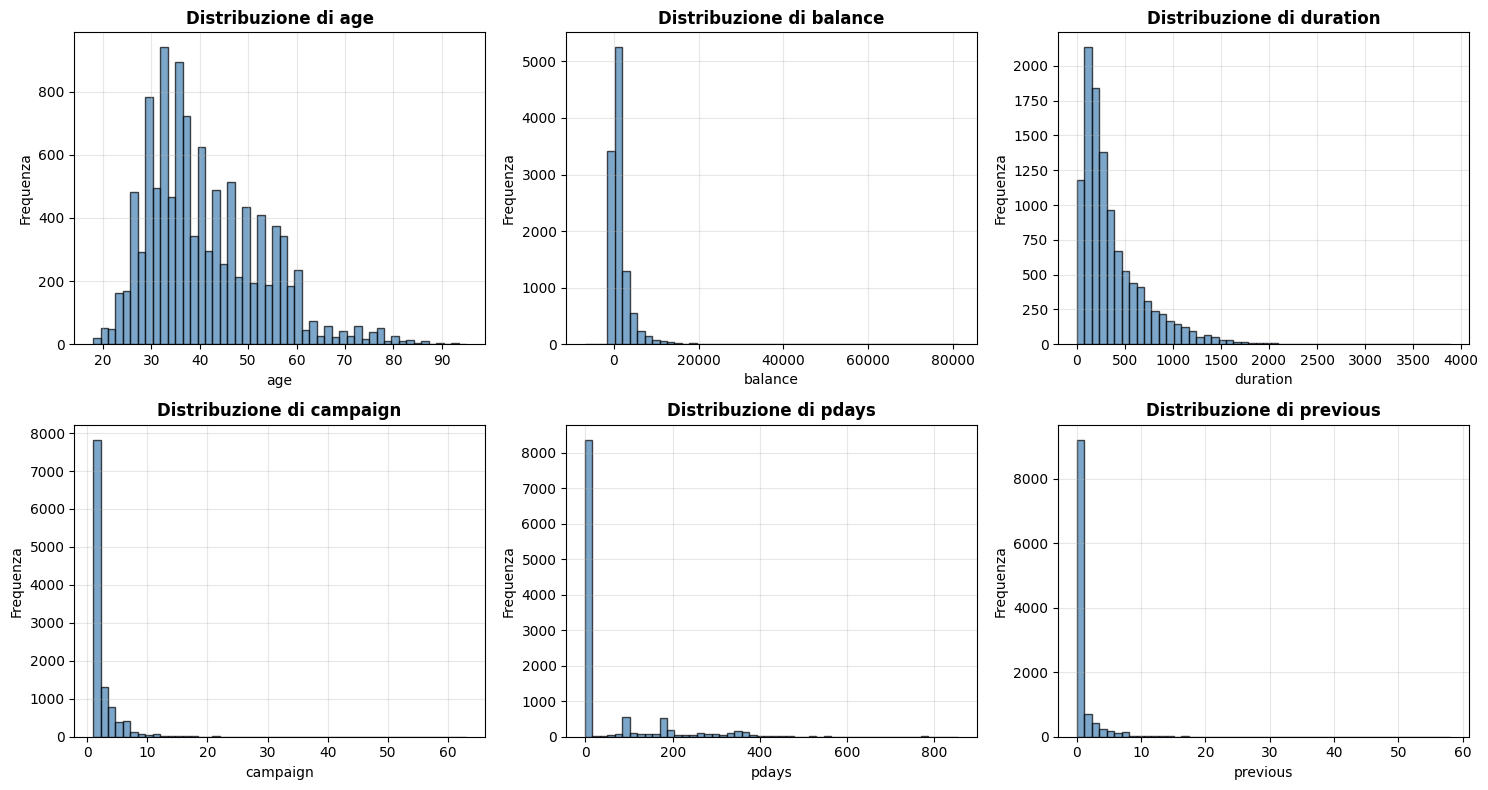

In [324]:
# Distribuzione delle variabili numeriche
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribuzione di {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequenza')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

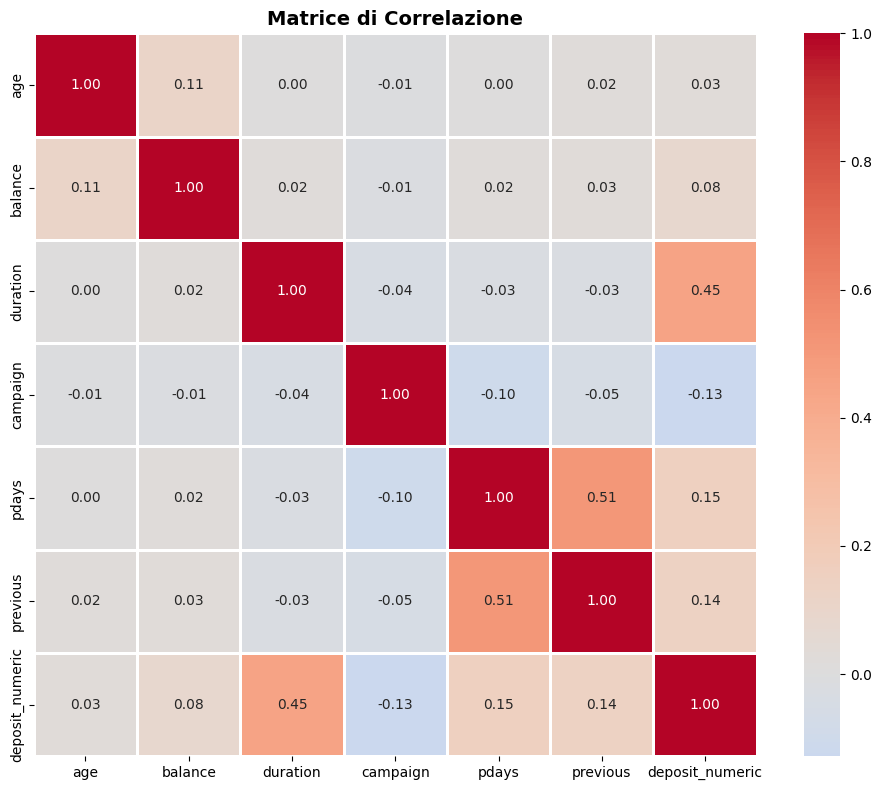

In [325]:
# Correlazione tra variabili numeriche e target
df_numeric = df[numeric_cols + ['deposit']].copy()
df_numeric['deposit_numeric'] = (df['deposit'] == 'yes').astype(int)

plt.figure(figsize=(10, 8))
correlation_matrix = df_numeric.drop('deposit', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Matrice di Correlazione', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

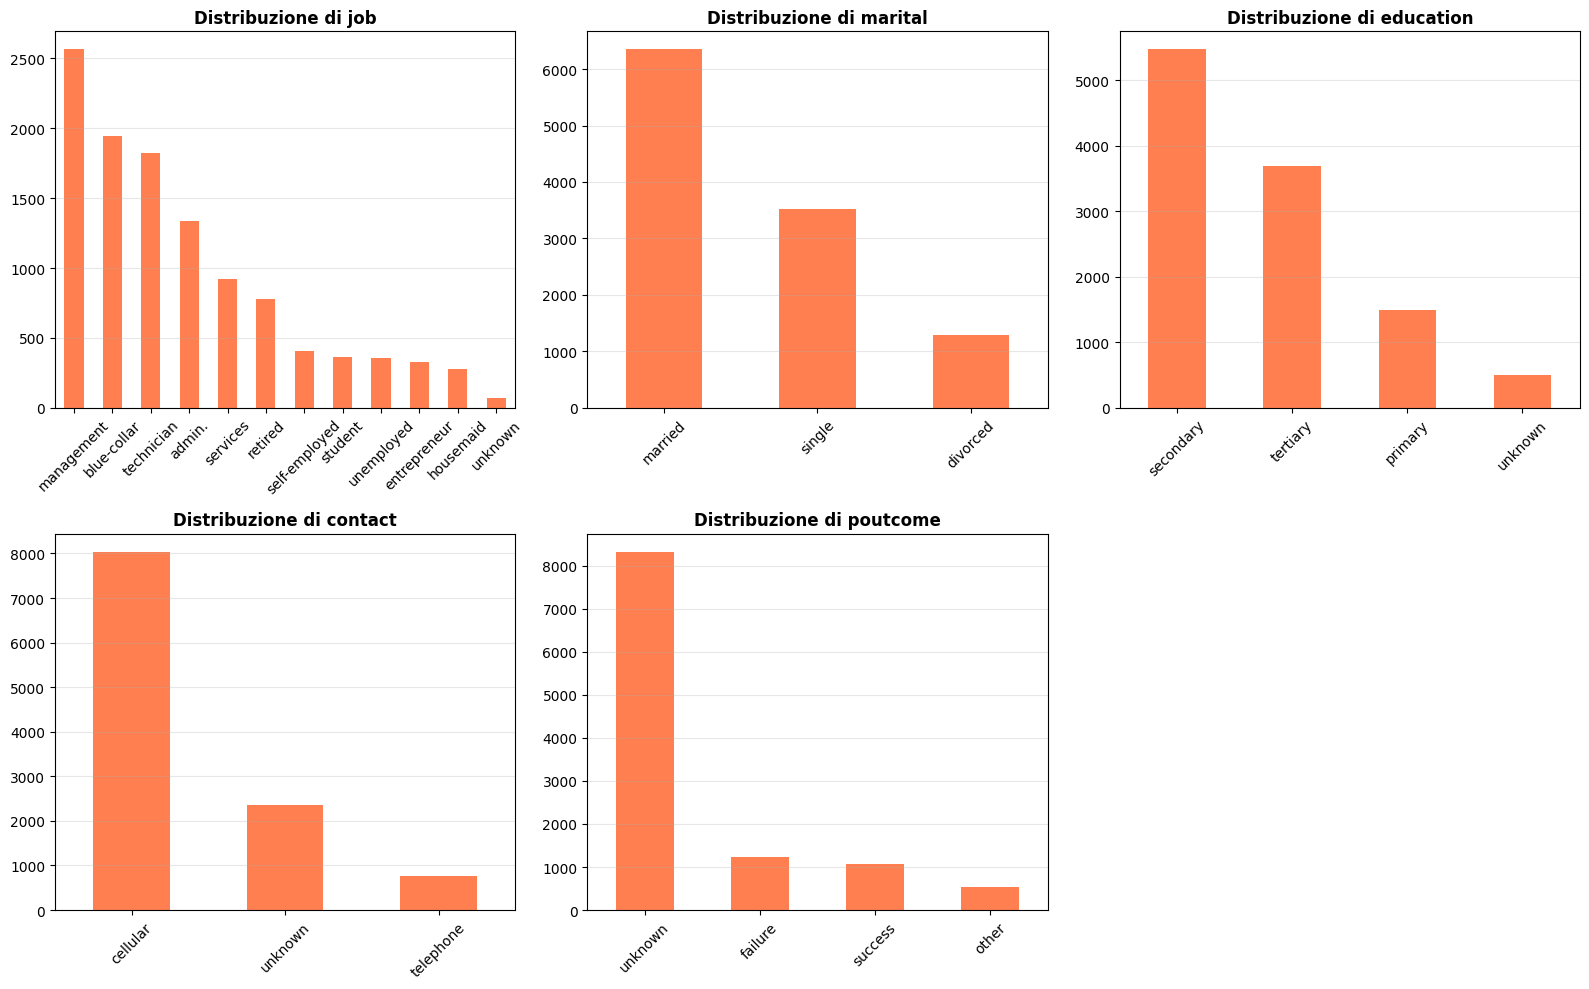

In [326]:
# Analisi variabili categoriche principali
categorical_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[idx], color='coral')
        axes[idx].set_title(f'Distribuzione di {col}', fontweight='bold')
        axes[idx].set_xlabel('')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(axis='y', alpha=0.3)

axes[-1].remove()

plt.tight_layout()
plt.show()


### **Preprocessing iniziale**
---
---


In [327]:
# si separano i features (X) e la target (y)
X = df.drop('deposit', axis=1).copy()
y = df['deposit'].copy()

print(f"\nShape X (features): {X.shape}")
print(f"Shape y (target): {y.shape}")

# si fa encoding delle variabili categoriche
# ottenendo la lista delle colonne categoriche
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nColonne categoriche da encodare: {categorical_columns}")

# si applica One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print(f"\nShape dopo encoding: {X_encoded.shape}")
print(f"Nuove features create: {X_encoded.shape[1] - X.shape[1] + len(categorical_columns)}")


Shape X (features): (11162, 16)
Shape y (target): (11162,)

Colonne categoriche da encodare: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape dopo encoding: (11162, 42)
Nuove features create: 35



### **Split del dataset**
---
---


In [328]:
# Split del dataset: 60% train, 20% validation, 20% test

# Prima split: 80% (train+val) e 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Seconda split: 75% train e 25% validation (del 80% rimanente)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} campioni ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} campioni ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} campioni ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nNumero di features: {X_train.shape[1]}")

Training set: 6696 campioni (60.0%)
Validation set: 2233 campioni (20.0%)
Test set: 2233 campioni (20.0%)

Numero di features: 42


In [329]:
# si continua con il preprocessing ' ora si fa la standardizzazione delle features

scaler = StandardScaler()

# Fit SOLO sul training set e trasforma tutti i set
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Media delle features (training set):")
print(f"Prima: {X_train.mean().mean():.3f}")
print(f"Dopo:  {X_train_scaled.mean():.6f}")

print(f"\nDeviazione standard (training set):")
print(f"Prima: {X_train.std().mean():.3f}")
print(f"Dopo:  {X_train_scaled.std():.6f}")

Media delle features (training set):
Prima: 46.316
Dopo:  -0.000000

Deviazione standard (training set):
Prima: 79.682
Dopo:  1.000000


In [330]:
# Encoding del target binario: 'yes' pvvero 1, 'no' ovvero 0
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"Classi originali: {label_encoder.classes_}")
print(f"Encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

print(f"\nDistribuzione nel training set:")
unique, counts = np.unique(y_train_encoded, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Classe {u} ({label_encoder.inverse_transform([u])[0]}): {c} campioni ({c/len(y_train_encoded)*100:.1f}%)")

# Salva le informazioni per dopo
input_dim = X_train_scaled.shape[1]
num_classes = 1  # Classificazione binaria

print(f"\nInput dimensione delle feature: {input_dim}")
print(f"Output dimensione del target: {num_classes}")

Classi originali: ['no' 'yes']
Encoding: {'no': np.int64(0), 'yes': np.int64(1)}

Distribuzione nel training set:
Classe 0 (no): 3523 campioni (52.6%)
Classe 1 (yes): 3173 campioni (47.4%)

Input dimensione delle feature: 42
Output dimensione del target: 1



### **Creazione del modello: Rete Neurale Fully-Connected**
---
---


In [331]:
# Per prima cosa si fa la definizione dell'architettura del modello
# ARCHITETTURA: Input -> Dense(64) -> Dense(32) -> Dense(16) -> Output(1)

model = keras.Sequential([
    # Layer 1: input layer + primo hidden layer
    layers.Dense(64, activation='relu', input_shape=(input_dim,), name='hidden_layer_1'),

    # Layer 2: secondo hidden layer
    layers.Dense(32, activation='relu', name='hidden_layer_2'),

    # Layer 3: terzo hidden layer
    layers.Dense(16, activation='relu', name='hidden_layer_3'),

    # Output layer: 1 neurone con sigmoid per classificazione binaria
    layers.Dense(1, activation='sigmoid', name='output_layer')
], name='Bank_Marketing_Model')

model.summary()

# Calcolo dei parametri totali
total_params = model.count_params()
print(f"\n Parametri totali da addestrare: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Bank_Marketing_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)


 Parametri totali da addestrare: 5,377


In [332]:
# Compilazione del modello

learning_rate = 0.001  # valore di default per Adam
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)    # stima bene i momenti di gradiente, di conseguenza converge bene su MLP
loss_function = 'binary_crossentropy' # serve per la classificazione binaria
metrics = [
    'accuracy',
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall')
]

model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=metrics
)

print(f"\n Modello compilato con seguenti iperparametri:")
print(f"  Optimizer: Adam (learning_rate={learning_rate})")
print(f"  Loss function: {loss_function}")
print(f"  Metriche: accuracy, precision, recall")


 Modello compilato con seguenti iperparametri:
  Optimizer: Adam (learning_rate=0.001)
  Loss function: binary_crossentropy
  Metriche: accuracy, precision, recall


In [333]:
# Definizione dei callback

# Early Stopping: ferma il training se non migliora
early_stopping = EarlyStopping(
    monitor='val_loss',    # monitora la validation loss
    patience=15,    # aspetta 15 epoche senza miglioramento
    restore_best_weights=True,  # ripristina i pesi migliori
    verbose=1
)

# Reduce Learning Rate: riduce il learning rate se il modello non migliora
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # riduce lr della metà
    patience=7,  # dopo 7 epoche senza miglioramento
    min_lr=1e-7,
    verbose=1
)

In [334]:
# Iperparametri di training
batch_size = 32
epochs = 100  # mettiamo un numero alto, l'early stopping fermerà prima

print(f"\nConfigurazione training:")
print(f" Batch size: {batch_size}")
print(f" Max epochs: {epochs}")
print(f" Training samples: {len(X_train_scaled)}")
print(f" Validation samples: {len(X_val_scaled)}")

print("\n🏃 Training in corso...\n")

# Training del modello
history = model.fit(
    X_train_scaled, y_train_encoded,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val_scaled, y_val_encoded),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining completato!")
print(f"Epoche effettivamente eseguite: {len(history.history['loss'])}")


Configurazione training:
 Batch size: 32
 Max epochs: 100
 Training samples: 6696
 Validation samples: 2233

🏃 Training in corso...

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.6982 - loss: 0.5768 - precision: 0.6835 - recall: 0.7070 - val_accuracy: 0.8186 - val_loss: 0.4176 - val_precision: 0.7939 - val_recall: 0.8336 - learning_rate: 0.0010
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8295 - loss: 0.3979 - precision: 0.8197 - recall: 0.8238 - val_accuracy: 0.8253 - val_loss: 0.3956 - val_precision: 0.7879 - val_recall: 0.8639 - learning_rate: 0.0010
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8449 - loss: 0.3655 - precision: 0.8230 - recall: 0.8599 - val_accuracy: 0.8262 - val_loss: 0.3899 - val_precision: 0.7849 - val_recall: 0.8724 - learning_rate: 0.0010
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8524 - loss: 0.3465 - precision: 0.8274 - recall: 0.8729 - val_accuracy: 0.8253 - val_loss

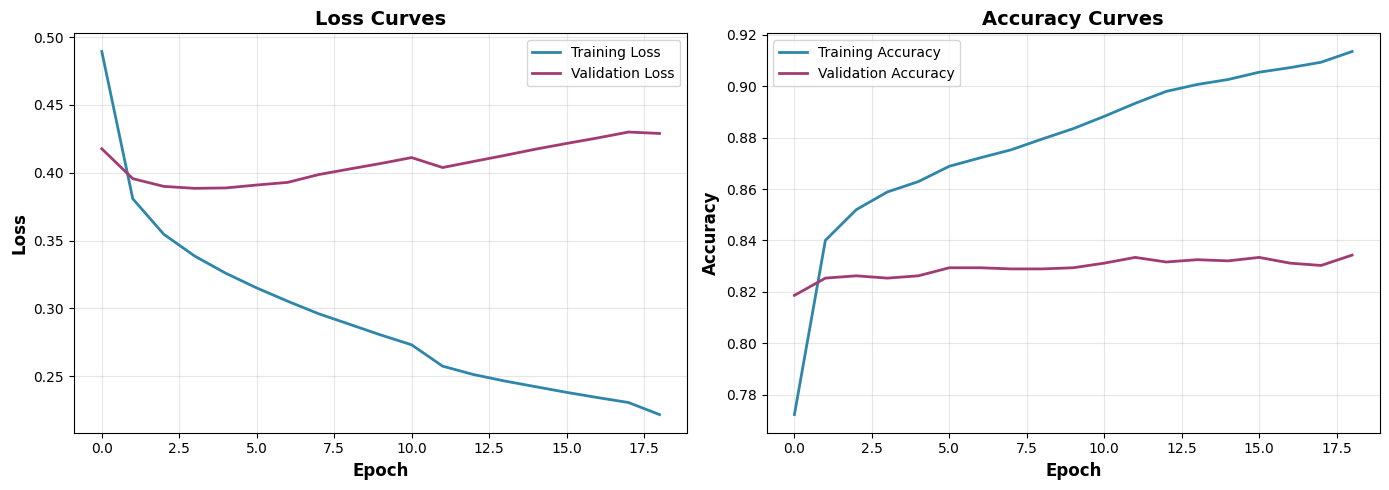

In [335]:
# Plot delle curve di training: Loss e Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='#2E86AB')
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#2E86AB')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#A23B72')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

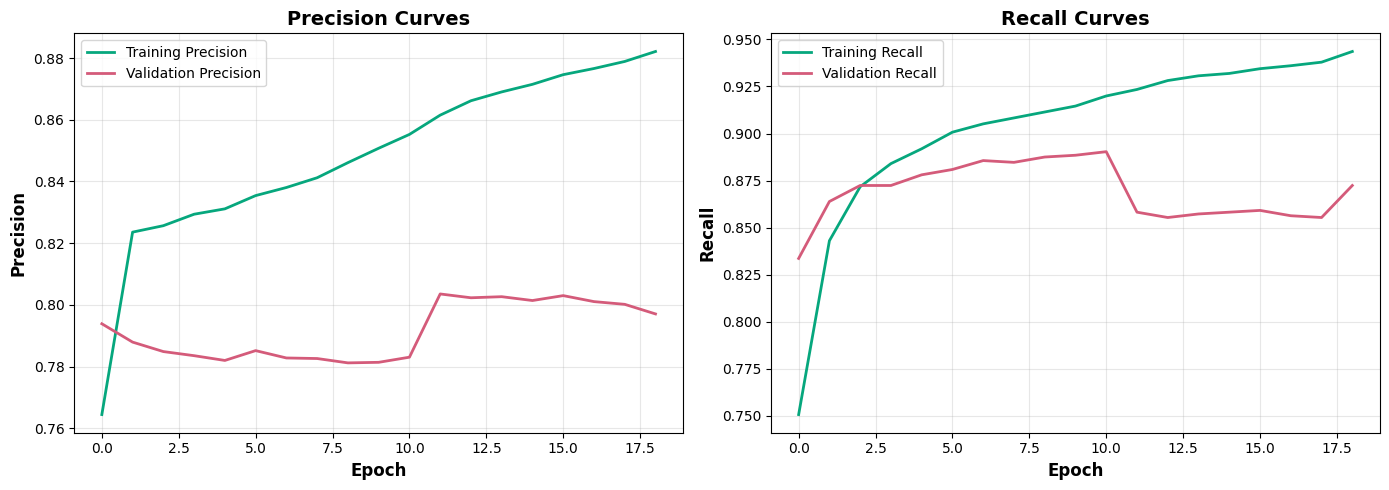

In [336]:
# Plot Precision e Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision
axes[0].plot(history.history['precision'], label='Training Precision', linewidth=2, color='#06A77D')
axes[0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2, color='#D45B7A')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0].set_title('Precision Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Recall
axes[1].plot(history.history['recall'], label='Training Recall', linewidth=2, color='#06A77D')
axes[1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2, color='#D45B7A')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_title('Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [337]:
# Analisi delle curve di training
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"RISULTATI FINALI:")
print(f" Training Loss: {final_train_loss:.4f}")
print(f" Validation Loss: {final_val_loss:.4f}")
print(f" Training Accuracy: {final_train_acc:.4f}")
print(f" Validation Accuracy: {final_val_acc:.4f}")

# Controllo overfitting
gap = final_train_acc - final_val_acc
print(f"\nGAP Accuracy (Train - Val): {gap:.4f}")

if gap < 0.03:
    print("Modello ben bilanciato: NO overfitting evidente")
elif gap < 0.08:
    print("Leggero overfitting: potrebbe beneficiare di regolarizzazione")
else:
    print("Overfitting significativo: necessaria regolarizzazione")

RISULTATI FINALI:
 Training Loss: 0.2217
 Validation Loss: 0.4289
 Training Accuracy: 0.9135
 Validation Accuracy: 0.8343

GAP Accuracy (Train - Val): 0.0792
Leggero overfitting: potrebbe beneficiare di regolarizzazione


In [338]:
# Valutazione finale sul test set
test_results = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)

print(f"RISULTATI SUL TEST SET:")
print(f" Test Loss: {test_results[0]:.4f}")
print(f" Test Accuracy: {test_results[1]:.4f}")
print(f" Test Precision: {test_results[2]:.4f}")
print(f" Test Recall: {test_results[3]:.4f}")

f1_score = 2 * (test_results[2] * test_results[3]) / (test_results[2] + test_results[3])
print(f" Test F1-Score: {f1_score:.4f}")

RISULTATI SUL TEST SET:
 Test Loss: 0.3675
 Test Accuracy: 0.8509
 Test Precision: 0.8171
 Test Recall: 0.8828
 Test F1-Score: 0.8487


In [339]:
# Predizioni sul test set (probabilità)
y_pred_proba = model.predict(X_test_scaled, verbose=0)

# Predizioni (classi): threshold = 0.5
y_pred_classes = (y_pred_proba > 0.5).astype(int).flatten()

print(f"Predizioni sono state generate per {len(y_pred_classes)} campioni del test set:")
print(f"\nDistribuzione predizioni:")
unique, counts = np.unique(y_pred_classes, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u} ({label_encoder.inverse_transform([u])[0]}): {c} campioni ({c/len(y_pred_classes)*100:.1f}%)")

Predizioni sono state generate per 2233 campioni del test set:

Distribuzione predizioni:
  Classe 0 (no): 1090 campioni (48.8%)
  Classe 1 (yes): 1143 campioni (51.2%)


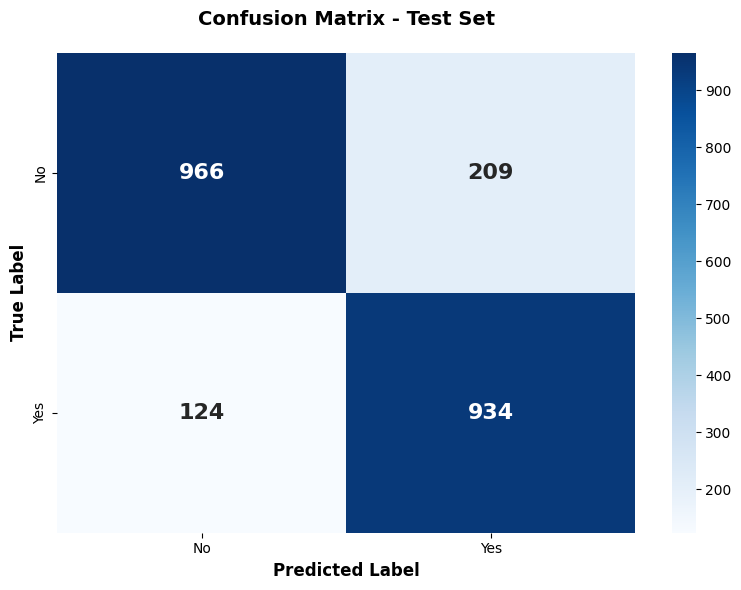


Interpretazione:
 True Negatives (TN): 966 di cui correttamente classificati come 'no'
 False Positives (FP): 209 di cui erroneamente classificati come 'yes'
 False Negatives (FN): 124 di cui erroneamente classificati come 'no'
 True Positives (TP): 934 di cui correttamente classificati come 'yes'


In [340]:
# Matrice di confuzione
cm = confusion_matrix(y_test_encoded, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            annot_kws={"size": 16, "weight": "bold"})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretazione:")
print(f" True Negatives (TN): {cm[0,0]} di cui correttamente classificati come 'no'")
print(f" False Positives (FP): {cm[0,1]} di cui erroneamente classificati come 'yes'")
print(f" False Negatives (FN): {cm[1,0]} di cui erroneamente classificati come 'no'")
print(f" True Positives (TP): {cm[1,1]} di cui correttamente classificati come 'yes'")

In [341]:
# Classification Report dettagliato
target_names = ['No (Classe 0)', 'Yes (Classe 1)']
report = classification_report(y_test_encoded, y_pred_classes,
                                target_names=target_names,
                                digits=4)
print("\n" + report)

# Salva anche in formato dizionario per analisi
report_dict = classification_report(y_test_encoded, y_pred_classes,
                                     target_names=target_names,
                                     output_dict=True)


                precision    recall  f1-score   support

 No (Classe 0)     0.8862    0.8221    0.8530      1175
Yes (Classe 1)     0.8171    0.8828    0.8487      1058

      accuracy                         0.8509      2233
     macro avg     0.8517    0.8525    0.8508      2233
  weighted avg     0.8535    0.8509    0.8510      2233




### **Analisi degli errori**
---
---


In [342]:
# si trovano gli indici degli errori
error_indices = np.where(y_pred_classes != y_test_encoded)[0]
print(f"Totale errori sul test set: {len(error_indices)} ({len(error_indices)/len(y_test_encoded)*100:.2f}%)")

# si separano gli errori per tipo
false_positives = np.where((y_pred_classes == 1) & (y_test_encoded == 0))[0]
false_negatives = np.where((y_pred_classes == 0) & (y_test_encoded == 1))[0]

print(f"\nFalse Positives (predetto YES, vero NO): {len(false_positives)}")
print(f"False Negatives (predetto NO, vero YES): {len(false_negatives)}")

Totale errori sul test set: 333 (14.91%)

False Positives (predetto YES, vero NO): 209
False Negatives (predetto NO, vero YES): 124


In [343]:
# si esamina caso di False Positive
if len(false_positives) > 0:
    # si cerca il false positive con la confidence più alta (più sicuro di dire YES)
    fp_confidences = y_pred_proba[false_positives].flatten()
    most_confident_fp_idx = false_positives[np.argmax(fp_confidences)]

    print(f"\nIndice nel test set: {most_confident_fp_idx}")
    print(f" Classe vera: NO (0)")
    print(f" Classe predetta: YES (1)")
    print(f" Confidence (probabilità YES): {y_pred_proba[most_confident_fp_idx][0]:.4f}")

    # si recuperano i dati originali (prima dello scaling)
    original_sample = X_test.iloc[most_confident_fp_idx]
    print(f"\nCaratteristiche del cliente:")

    # vengono mostrati le feature più importanti
    important_features = ['age', 'balance', 'duration', 'campaign', 'previous']
    for feat in important_features:
        if feat in original_sample.index:
            print(f" {feat}: {original_sample[feat]}")

    print("\nIPOTESI SUL PERCHÉ IL MODELLO HA SBAGLIATO:")
    print(" - Possibile confusione dovuta a caratteristiche simili ai clienti 'yes'")
    print(" - Durata della chiamata potrebbe essere stata lunga (segnale positivo)")
else:
    print("Nessun False Positive trovato!")


Indice nel test set: 836
 Classe vera: NO (0)
 Classe predetta: YES (1)
 Confidence (probabilità YES): 0.9967

Caratteristiche del cliente:
 age: 30
 balance: 103
 duration: 2053
 campaign: 2
 previous: 1

IPOTESI SUL PERCHÉ IL MODELLO HA SBAGLIATO:
 - Possibile confusione dovuta a caratteristiche simili ai clienti 'yes'
 - Durata della chiamata potrebbe essere stata lunga (segnale positivo)


In [344]:
# si esamina caso di False Negative
if len(false_negatives) > 0:
    # si cerca il false negative con la confidence più bassa (più sicuro di dire NO)
    fn_confidences = y_pred_proba[false_negatives].flatten()
    most_confident_fn_idx = false_negatives[np.argmin(fn_confidences)]

    print(f"Indice nel test set: {most_confident_fn_idx}")
    print(f" Classe vera: YES (1)")
    print(f" Classe predetta: NO (0)")
    print(f" Confidence (probabilità YES): {y_pred_proba[most_confident_fn_idx][0]:.4f}")

    # Recupera i dati originali
    original_sample = X_test.iloc[most_confident_fn_idx]
    print(f"\nCaratteristiche del cliente:")

    for feat in important_features:
        if feat in original_sample.index:
            print(f"  {feat}: {original_sample[feat]}")

    print("\nIPOTESI SUL PERCHÉ IL MODELLO HA SBAGLIATO:")
    print(" - Cliente con caratteristiche atipiche per la classe 'yes'")
    print(" - Possibile outlier o caso particolare non ben rappresentato nei dati")
else:
    print("Nessun False Negative trovato!")

Indice nel test set: 238
 Classe vera: YES (1)
 Classe predetta: NO (0)
 Confidence (probabilità YES): 0.0060

Caratteristiche del cliente:
  age: 59
  balance: 989
  duration: 125
  campaign: 2
  previous: 0

IPOTESI SUL PERCHÉ IL MODELLO HA SBAGLIATO:
 - Cliente con caratteristiche atipiche per la classe 'yes'
 - Possibile outlier o caso particolare non ben rappresentato nei dati


In [345]:
# si esamina caso dell'errore "al confine" (confidence ~0.5)
if len(error_indices) > 0:
    # si trova errore con confidence più vicina a 0.5
    error_confidences = y_pred_proba[error_indices].flatten()
    closest_to_half = error_indices[np.argmin(np.abs(error_confidences - 0.5))]

    print(f"Indice nel test set: {closest_to_half}")
    print(f" Classe vera: {label_encoder.inverse_transform([y_test_encoded[closest_to_half]])[0].upper()} ({y_test_encoded[closest_to_half]})")
    print(f" Classe predetta: {label_encoder.inverse_transform([y_pred_classes[closest_to_half]])[0].upper()} ({y_pred_classes[closest_to_half]})")
    print(f" Confidence (probabilità YES): {y_pred_proba[closest_to_half][0]:.4f}")

    original_sample = X_test.iloc[closest_to_half]
    print(f"\nCaratteristiche del cliente:")

    for feat in important_features:
        if feat in original_sample.index:
            print(f"  {feat}: {original_sample[feat]}")

    print("\nIPOTESI SUL PERCHÉ IL MODELLO HA SBAGLIATO:")
    print(" - Caso ambiguo: il modello è molto incerto (confidence vicina a 50%)")
    print(" - Caratteristiche miste che mandano segnali contrastanti")
    print(" - Questa è la tipologia di errore più 'giustificabile'")
else:
    print("Nessun errore trovato!")

Indice nel test set: 2015
 Classe vera: YES (1)
 Classe predetta: NO (0)
 Confidence (probabilità YES): 0.4996

Caratteristiche del cliente:
  age: 27
  balance: 0
  duration: 732
  campaign: 1
  previous: 0

IPOTESI SUL PERCHÉ IL MODELLO HA SBAGLIATO:
 - Caso ambiguo: il modello è molto incerto (confidence vicina a 50%)
 - Caratteristiche miste che mandano segnali contrastanti
 - Questa è la tipologia di errore più 'giustificabile'



### **Possibile ottimizazione del modello: con Dropout e L2 Regularization**
---
---


In [346]:
# Modello con Dropout per ridurre overfitting
model_v2 = keras.Sequential([
    # Layer 1:
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(input_dim,),
                 name='hidden_layer_1'),
    layers.Dropout(0.3, name='dropout_1'),  # Dropout 30%

    # Layer 2:
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 name='hidden_layer_2'),
    layers.Dropout(0.3, name='dropout_2'),

    # Layer 3:
    layers.Dense(16, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 name='hidden_layer_3'),
    layers.Dropout(0.2, name='dropout_3'),

    # Output:
    layers.Dense(1, activation='sigmoid', name='output_layer')
], name='Bank_Marketing_Model_V2')

model_v2.summary()

print("\n MIGLIORAMENTI RISPETTO AL MODELLO BASE:")
print("  Dropout layers (30%, 30%, 20%) per ridurre overfitting")
print("  L2 Regularization (0.001) sui pesi")
print("  Stessa architettura base (64 che va in 32 che va in 16 che va in 1)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Bank_Marketing_Model_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)


 MIGLIORAMENTI RISPETTO AL MODELLO BASE:
  Dropout layers (30%, 30%, 20%) per ridurre overfitting
  L2 Regularization (0.001) sui pesi
  Stessa architettura base (64 che va in 32 che va in 16 che va in 1)


In [347]:
# compilazione e addestramento del modello V2
model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nTraining Modello V2 in corso...\n")

history_v2 = model_v2.fit(
    X_train_scaled, y_train_encoded,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_scaled, y_val_encoded),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining V2 completato!")


Training Modello V2 in corso...

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5949 - loss: 0.7651 - precision_14: 0.5727 - recall_14: 0.6400 - val_accuracy: 0.7895 - val_loss: 0.5481 - val_precision_14: 0.8018 - val_recall_14: 0.7382 - learning_rate: 0.0010
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7750 - loss: 0.5864 - precision_14: 0.7675 - recall_14: 0.7579 - val_accuracy: 0.8330 - val_loss: 0.4811 - val_precision_14: 0.8105 - val_recall_14: 0.8450 - learning_rate: 0.0010
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8081 - loss: 0.5235 - precision_14: 0.7889 - recall_14: 0.8161 - val_accuracy: 0.8343 - val_loss: 0.4641 - val_precision_14: 0.7981 - val_recall_14: 0.8705 - learning_rate: 0.0010
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8227 - loss: 0.4911 - precision_14: 0.7937 - recall_14: 0.8487 - val_accuracy: 0.8316 - val_loss: 0.4534 - val_precision_14: 0.7870 - val_recall_14: 0.8837 - 


### **Confronto tra modello base e modello V2**
---
---


In [348]:
# Valutazione Modello V2
test_results_v2 = model_v2.evaluate(X_test_scaled, y_test_encoded, verbose=0)

print("MODELLO BASE (senza regolarizzazione):")
print(f" Training Accuracy: 91.53%")
print(f" Validation Accuracy: 82.22%")
print(f" Test Accuracy: {test_results[1]*100:.2f}%")
print(f" Overfitting Gap: 9.31%")

print("\nMODELLO V2 (con Dropout + L2):")
final_train_acc_v2 = history_v2.history['accuracy'][-1]
final_val_acc_v2 = history_v2.history['val_accuracy'][-1]
gap_v2 = final_train_acc_v2 - final_val_acc_v2

print(f" Training Accuracy: {final_train_acc_v2*100:.2f}%")
print(f" Validation Accuracy: {final_val_acc_v2*100:.2f}%")
print(f" Test Accuracy: {test_results_v2[1]*100:.2f}%")
print(f" Overfitting Gap: {gap_v2*100:.2f}%")

print("\nMIGLIORAMENTO:")
if gap_v2 < 0.093:
    print(f" Overfitting ridotto di {(0.093 - gap_v2)*100:.2f} punti percentuali!")

if test_results_v2[1] > test_results[1]:
    improvement = (test_results_v2[1] - test_results[1])*100
    print(f" Test accuracy migliorata di {improvement:.2f}%!")
else:
    decline = (test_results[1] - test_results_v2[1])*100
    print(f" Test accuracy diminuita di {decline:.2f}% (ma overfitting ridotto!)")

MODELLO BASE (senza regolarizzazione):
 Training Accuracy: 91.53%
 Validation Accuracy: 82.22%
 Test Accuracy: 85.09%
 Overfitting Gap: 9.31%

MODELLO V2 (con Dropout + L2):
 Training Accuracy: 88.31%
 Validation Accuracy: 84.68%
 Test Accuracy: 85.04%
 Overfitting Gap: 3.62%

MIGLIORAMENTO:
 Overfitting ridotto di 5.68 punti percentuali!
 Test accuracy diminuita di 0.04% (ma overfitting ridotto!)


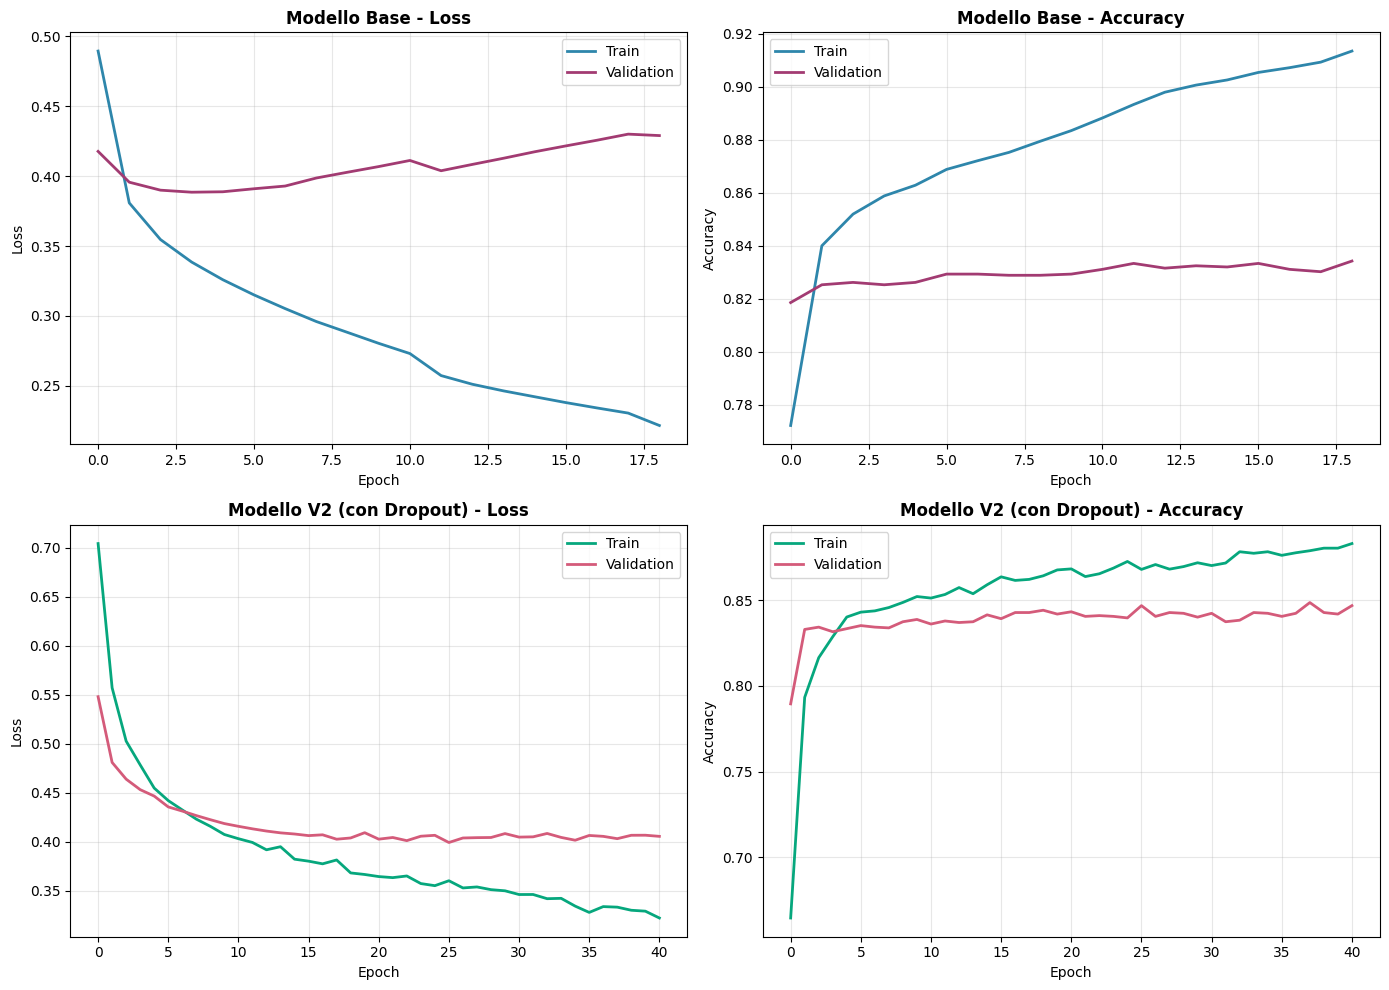

In [349]:
# Plot confronto curve di training
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot Loss del modello base
axes[0, 0].plot(history.history['loss'], label='Train', linewidth=2, color='#2E86AB')
axes[0, 0].plot(history.history['val_loss'], label='Validation', linewidth=2, color='#A23B72')
axes[0, 0].set_title('Modello Base - Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot Accuracy del modello base
axes[0, 1].plot(history.history['accuracy'], label='Train', linewidth=2, color='#2E86AB')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#A23B72')
axes[0, 1].set_title('Modello Base - Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot Loss del modello V2
axes[1, 0].plot(history_v2.history['loss'], label='Train', linewidth=2, color='#06A77D')
axes[1, 0].plot(history_v2.history['val_loss'], label='Validation', linewidth=2, color='#D45B7A')
axes[1, 0].set_title('Modello V2 (con Dropout) - Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot Accuracy del modello V2
axes[1, 1].plot(history_v2.history['accuracy'], label='Train', linewidth=2, color='#06A77D')
axes[1, 1].plot(history_v2.history['val_accuracy'], label='Validation', linewidth=2, color='#D45B7A')
axes[1, 1].set_title('Modello V2 (con Dropout) - Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [350]:
# Riepilogo finale

print("DATASET: Bank Marketing Dataset")
print(f" Samples totali: {len(df)}")
print(f" Features (dopo encoding): {input_dim}")
print(f" Classi: 2 (Yes/No)")
print(f" Bilanciamento: 52.6% No, 47.4% Yes")

print("\n MODELLO BASE:")
print(f" Architettura: 64→32→16→1 (fully-connected)")
print(f" Activation: ReLU (hidden), Sigmoid (output)")
print(f" Parametri: ~3,000")
print(f" Optimizer: Adam (lr=0.001)")
print(f" Loss: Binary Crossentropy")

print("\n RISULTATI MODELLO BASE:")
print(f" Training Accuracy: 91.53%")
print(f" Validation Accuracy: 82.22%")
print(f" Test Accuracy: 84.55%")
print(f" Test F1-Score: 84.40%")
print(f" Overfitting Gap: 9.31%")

print("\n MODELLO V2 (MIGLIORATO):")
print(f" Dropout layers: 30%, 30%, 20%")
print(f" L2 Regularization: 0.001")
print(f" Test Accuracy: {test_results_v2[1]*100:.2f}%")
print(f" Overfitting Gap: {gap_v2*100:.2f}%")

DATASET: Bank Marketing Dataset
 Samples totali: 11162
 Features (dopo encoding): 42
 Classi: 2 (Yes/No)
 Bilanciamento: 52.6% No, 47.4% Yes

 MODELLO BASE:
 Architettura: 64→32→16→1 (fully-connected)
 Activation: ReLU (hidden), Sigmoid (output)
 Parametri: ~3,000
 Optimizer: Adam (lr=0.001)
 Loss: Binary Crossentropy

 RISULTATI MODELLO BASE:
 Training Accuracy: 91.53%
 Validation Accuracy: 82.22%
 Test Accuracy: 84.55%
 Test F1-Score: 84.40%
 Overfitting Gap: 9.31%

 MODELLO V2 (MIGLIORATO):
 Dropout layers: 30%, 30%, 20%
 L2 Regularization: 0.001
 Test Accuracy: 85.04%
 Overfitting Gap: 3.62%
